<a href="https://colab.research.google.com/github/Zafeer-Sultan/Portfolio/blob/main/Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import requests

url = "https://api.adzuna.com/v1/api/jobs/gb/search/1"
params = {
    "app_id": "a596ebe6",
    "app_key": "a29ff4c19333432da833be536e3adcb8",
    "what": "data scientist",
    "where": "london",
    "results_per_page": 50,  # Fetch more data for training
    "content-type": "application/json"
}

response = requests.get(url, params=params)
data = response.json()
jobs = data["results"]


In [ ]:
df = pd.DataFrame([{
    "title": job.get("title"),
    "location": job.get("location", {}).get("display_name"),
    "category": job.get("category", {}).get("label"),
    "company": job.get("company", {}).get("display_name"),
    "contract_time": job.get("contract_time"),
    "contract_type": job.get("contract_type"),
    "salary_min": job.get("salary_min"),
    "salary_max": job.get("salary_max"),
    "description": job.get("description"),
    "created": job.get("created")
} for job in jobs])

df.head()

,title,location,category,company,contract_time,contract_type,salary_min,salary_max,description,created
0,Data Scientist,"Richmond, West London",IT Jobs,Datix Limited,None,permanent,49041.90,49041.90,RLDatix is on a mission to transform care deli...,2025-05-15T20:07:44Z
1,Senior Data Scientist,"Richmond, West London",IT Jobs,Datix Limited,None,permanent,52074.95,52074.95,RLDatix is on a mission to transform care deli...,2025-05-15T20:07:43Z
2,Senior Data Scientist,"North West London, London",IT Jobs,Saga Group Limited,None,permanent,70000.00,70000.00,"Senior Data Scientist Salary from £60,000 to £...",2025-05-06T19:09:41Z
3,Senior Data Scientist,"South East London, London",IT Jobs,ADLIB Recruitment,None,permanent,100000.00,100000.00,Investment Firm Build cutting-edge investment ...,2025-05-01T14:40:08Z
4,Data Science Manager,"South East London, London",IT Jobs,ADLIB Recruitment,None,permanent,90000.00,90000.00,Shape the future of AI in healthcare & lead a ...,2025-05-02T11:20:03Z


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          50 non-null     object 
 1   location       50 non-null     object 
 2   category       50 non-null     object 
 3   company        50 non-null     object 
 4   contract_time  2 non-null      object 
 5   contract_type  12 non-null     object 
 6   salary_min     50 non-null     float64
 7   salary_max     50 non-null     float64
 8   description    50 non-null     object 
 9   created        50 non-null     object 
dtypes: float64(2), object(8)
memory usage: 4.0+ KB


In [ ]:
df.isna().sum()

,0
title,0
location,0
category,0
company,0
contract_time,48
contract_type,38
salary_min,0
salary_max,0
description,0
created,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# For categorical data
label_encoder = LabelEncoder()
df['contract_time'] = label_encoder.fit_transform(df['contract_time'])
df['contract_type'] = label_encoder.fit_transform(df['contract_type'])

In [ ]:
df = pd.get_dummies(df, columns=['contract_time', 'contract_type'], drop_first=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            50 non-null     object 
 1   location         50 non-null     object 
 2   category         50 non-null     object 
 3   company          50 non-null     object 
 4   salary_min       50 non-null     float64
 5   salary_max       50 non-null     float64
 6   description      50 non-null     object 
 7   created          50 non-null     object 
 8   contract_time_1  50 non-null     bool   
 9   contract_type_1  50 non-null     bool   
 10  contract_type_2  50 non-null     bool   
dtypes: bool(3), float64(2), object(6)
memory usage: 3.4+ KB


In [ ]:
from sklearn.impute import KNNImputer

# For numeric data imputation
imputer = KNNImputer(n_neighbors=5)
df[['contract_time_1', 'contract_type_1','contract_type_2']] = imputer.fit_transform(df[['contract_time_1', 'contract_type_1','contract_type_2']])


In [ ]:
df.isna().sum()

,0
title,0
location,0
category,0
company,0
salary_min,0
salary_max,0
description,0
created,0
contract_time_1,0
contract_type_1,0


In [ ]:
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2

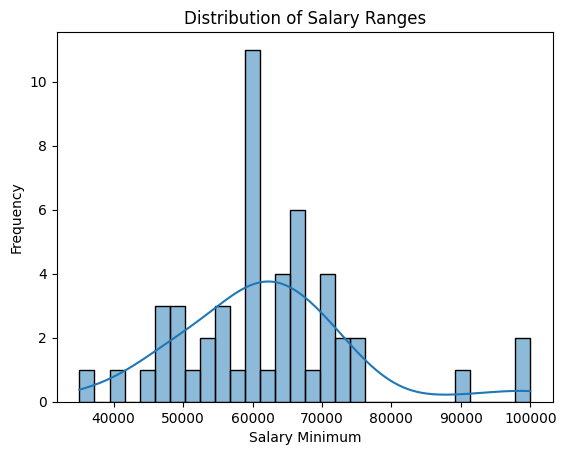

In [ ]:
sns.histplot(df['salary_avg'], bins=30, kde=True)
plt.xlabel('Salary Minimum')
plt.ylabel('Frequency')
plt.title('Distribution of Salary Ranges')
plt.show()

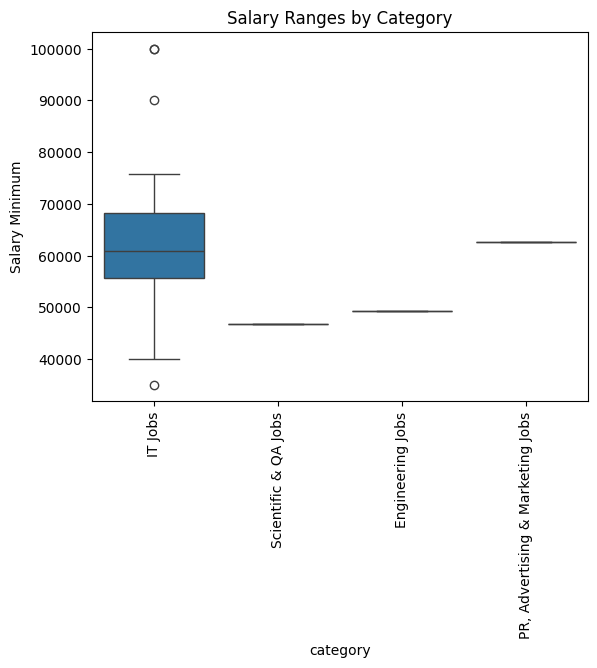

In [ ]:
sns.boxplot(data=df, x='category', y='salary_avg')
plt.ylabel('Salary Minimum')
plt.title('Salary Ranges by Category')
plt.xticks(rotation=90)
plt.show()


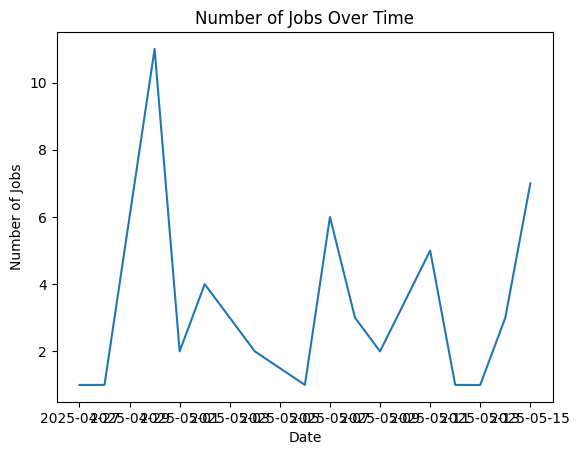

In [ ]:
df['created'] = pd.to_datetime(df['created'])
df['created'].dt.date.value_counts().sort_index().plot(kind='line')
plt.xlabel('Date')
plt.ylabel('Number of Jobs')
plt.title('Number of Jobs Over Time')
plt.show()

<Axes: xlabel='count', ylabel='category'>

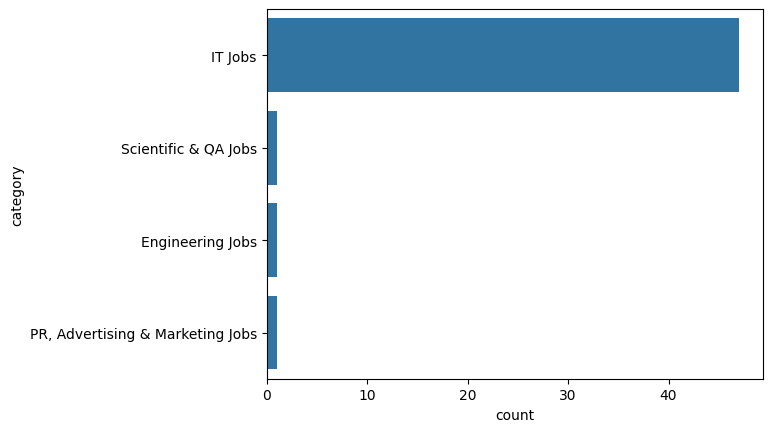

In [ ]:
sns.countplot(data=df, y='category', order=df['category'].value_counts().index)


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

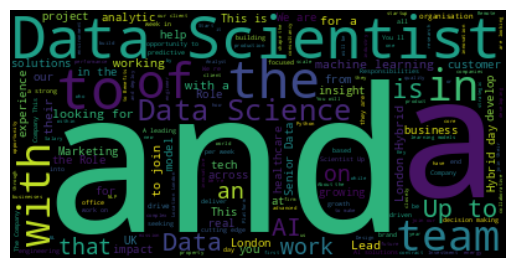

In [ ]:
from wordcloud import WordCloud
text = ' '.join(df['description'])
wordcloud = WordCloud(stopwords='english').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')


In [ ]:
df = pd.get_dummies(df, columns=['contract_type_1', 'contract_type_2', 'contract_time_1', 'category', 'location'], drop_first=True)


In [ ]:
df['remote'] = df['description'].str.contains('remote|work from home', case=False, na=False).astype(int)
df['python'] = df['description'].str.contains('python', case=False, na=False).astype(int)
df['excel'] = df['description'].str.contains('excel', case=False, na=False).astype(int)
df['sql'] = df['description'].str.contains('sql', case=False, na=False).astype(int)


In [ ]:
df.head()

,title,company,salary_min,salary_max,description,created,salary_avg,contract_type_1_1.0,contract_type_2_1.0,contract_time_1_1.0,category_IT Jobs,"category_PR, Advertising & Marketing Jobs",category_Scientific & QA Jobs,"location_North West London, London","location_Richmond, West London","location_South East London, London",remote,python,excel,sql
0,Data Scientist,Datix Limited,49041.90,49041.90,RLDatix is on a mission to transform care deli...,2025-05-15 20:07:44+00:00,49041.90,True,False,True,True,False,False,False,True,False,0,0,0,0
1,Senior Data Scientist,Datix Limited,52074.95,52074.95,RLDatix is on a mission to transform care deli...,2025-05-15 20:07:43+00:00,52074.95,True,False,True,True,False,False,False,True,False,0,0,0,0
2,Senior Data Scientist,Saga Group Limited,70000.00,70000.00,"Senior Data Scientist Salary from £60,000 to £...",2025-05-06 19:09:41+00:00,70000.00,True,False,True,True,False,False,True,False,False,0,0,0,0
3,Senior Data Scientist,ADLIB Recruitment,100000.00,100000.00,Investment Firm Build cutting-edge investment ...,2025-05-01 14:40:08+00:00,100000.00,True,False,True,True,False,False,False,False,True,0,0,0,0
4,Data Science Manager,ADLIB Recruitment,90000.00,90000.00,Shape the future of AI in healthcare & lead a ...,2025-05-02 11:20:03+00:00,90000.00,True,False,True,True,False,False,False,False,True,0,0,0,0


In [ ]:
df['title_len'] = df['title'].str.len()
df['desc_len'] = df['description'].str.len()


In [ ]:
X = df.drop(['salary_avg'], axis=1)
y = df['salary_avg']


In [ ]:
# Example: Predicting minimum salary
target = 'salary_min'

# Drop identifiers, text-heavy or redundant columns
features = df.drop(columns=[target, 'salary_max', 'created','salary_avg', 'title', 'description'])

# Select only numeric or encoded categorical columns
X = pd.get_dummies(features, drop_first=True)
y = df[target]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n{name}:")
    print(f"R² Score: {r2:.2f}")
    print(f"MAE: £{mae:,.0f}")
    print(f"RMSE: £{rmse:,.0f}")



Linear Regression:
R² Score: -2.17
MAE: £8,948
RMSE: £10,917

Random Forest:
R² Score: -0.65
MAE: £6,670
RMSE: £7,879

Gradient Boosting:
R² Score: -1.03
MAE: £7,036
RMSE: £8,739


In [ ]:
print(X.columns)


Index(['salary_avg', 'contract_type_1_1.0', 'contract_type_2_1.0',
       'contract_time_1_1.0', 'category_IT Jobs',
       'category_PR, Advertising & Marketing Jobs',
       'category_Scientific & QA Jobs', 'location_North West London, London',
       'location_Richmond, West London', 'location_South East London, London',
       'remote', 'python', 'excel', 'sql', 'title_len', 'desc_len',
       'company_Airswift', 'company_Arrows', 'company_BrandDelta',
       'company_Careerwise', 'company_Datatech Analytics',
       'company_Datix Limited', 'company_Eames Consulting', 'company_Glass.AI',
       'company_Harnham', 'company_Intellect Group', 'company_InterEx Group',
       'company_JSS Search', 'company_Lorien', 'company_MCS Group',
       'company_Nicholson Glover', 'company_Oliver Bernard',
       'company_Peregrine', 'company_Randstad Digital',
       'company_Response Informatics', 'company_Saga Group Limited',
       'company_Synergetic', 'company_Understanding Recruitment',
  

In [ ]:
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)


Train set size: (40, 39)
Test set size: (10, 39)


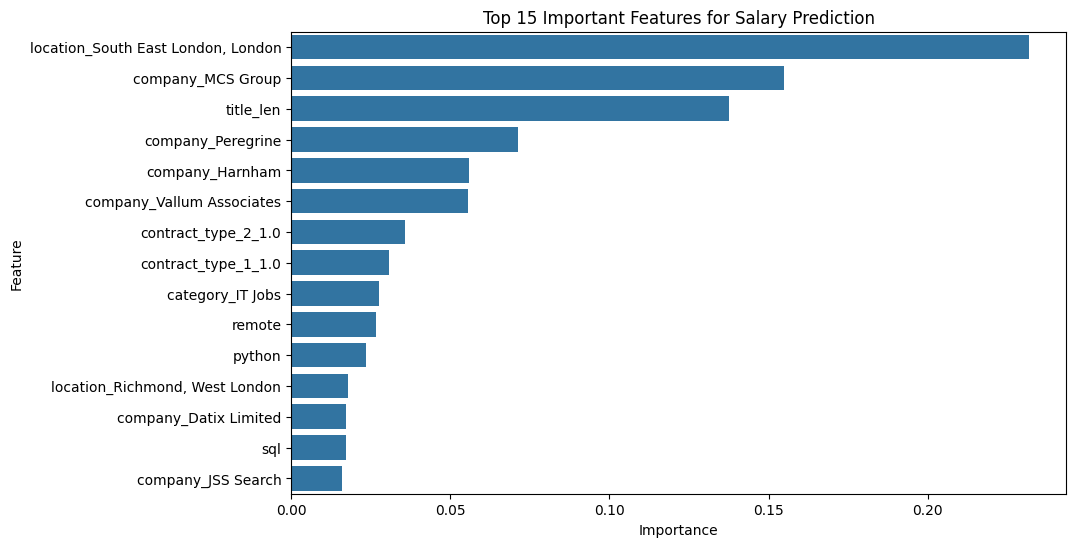

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_imp = models["Random Forest"].feature_importances_
feat_names = X.columns

imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': feat_imp})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df)
plt.title('Top 15 Important Features for Salary Prediction')
plt.show()


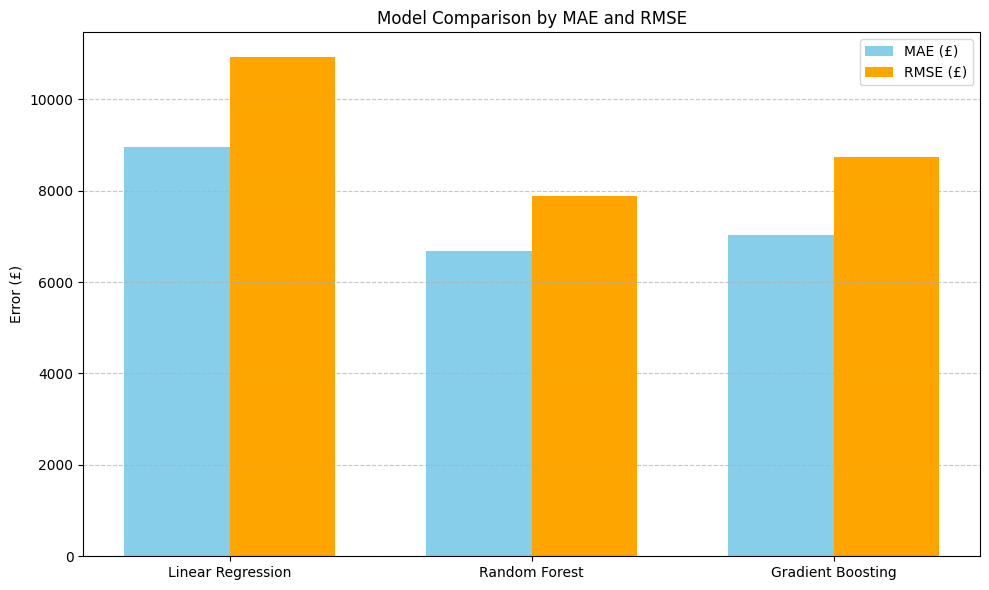

In [ ]:
import matplotlib.pyplot as plt

# Store results
results = {
    'Linear Regression': {'MAE': 8948, 'RMSE': 10917},
    'Random Forest': {'MAE': 6670, 'RMSE': 7879},
    'Gradient Boosting': {'MAE': 7036, 'RMSE': 8739}
}

# Extract for plotting
models = list(results.keys())
mae_values = [results[m]['MAE'] for m in models]
rmse_values = [results[m]['RMSE'] for m in models]

x = range(len(models))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(10,6))
ax.bar([p - width/2 for p in x], mae_values, width, label='MAE (£)', color='skyblue')
ax.bar([p + width/2 for p in x], rmse_values, width, label='RMSE (£)', color='orange')

# Labels and titles
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Error (£)')
ax.set_title('Model Comparison by MAE and RMSE')
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Optional: Set a random seed
RANDOM_STATE = 42


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_params,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best Random Forest Parameters:", rf_grid.best_params_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_params,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_
print("Best Gradient Boosting Parameters:", gb_grid.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\n{name}:")
    print(f"R² Score: {r2:.2f}")
    print(f"MAE: £{mae:,.0f}")
    print(f"RMSE: £{rmse:,.0f}")

evaluate_model("Tuned Random Forest", best_rf, X_test, y_test)
evaluate_model("Tuned Gradient Boosting", best_gb, X_test, y_test)



Tuned Random Forest:
R² Score: -0.63
MAE: £6,497
RMSE: £7,824

Tuned Gradient Boosting:
R² Score: -1.09
MAE: £7,655
RMSE: £8,856


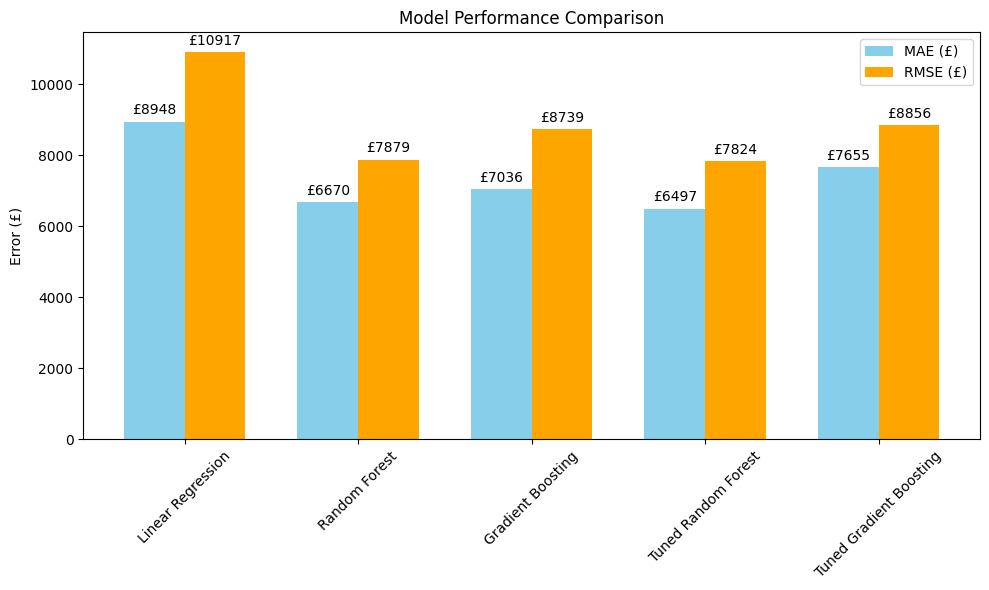

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

results = {
    "Linear Regression": {"MAE": 8948, "RMSE": 10917},
    "Random Forest": {"MAE": 6670, "RMSE": 7879},
    "Gradient Boosting": {"MAE": 7036, "RMSE": 8739},
    "Tuned Random Forest": {"MAE": 6497, "RMSE": 7824},
    "Tuned Gradient Boosting": {"MAE": 7655, "RMSE": 8856}
}

models = list(results.keys())
mae = [results[m]["MAE"] for m in models]
rmse = [results[m]["RMSE"] for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
mae_bars = ax.bar(x - width/2, mae, width, label='MAE (£)', color='skyblue')
rmse_bars = ax.bar(x + width/2, rmse, width, label='RMSE (£)', color='orange')

ax.set_ylabel('Error (£)')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)
ax.legend()
ax.bar_label(mae_bars, fmt='£%.0f', padding=3)
ax.bar_label(rmse_bars, fmt='£%.0f', padding=3)
plt.tight_layout()
plt.show()


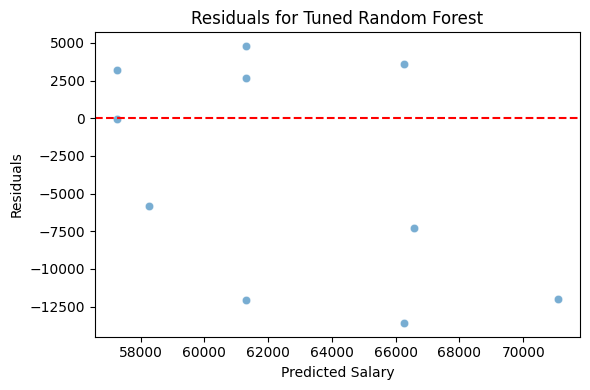

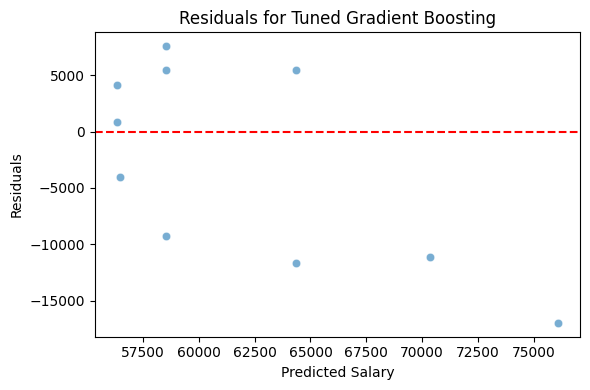

In [ ]:
import seaborn as sns

def plot_residuals(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(0, linestyle='--', color='red')
    plt.title(f"Residuals for {title}")
    plt.xlabel("Predicted Salary")
    plt.ylabel("Residuals")
    plt.tight_layout()
    plt.show()

plot_residuals(best_rf, X_test, y_test, "Tuned Random Forest")
plot_residuals(best_gb, X_test, y_test, "Tuned Gradient Boosting")
